In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv('/content/Global_Pollution_Analysis.csv')

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

In [4]:
df.isnull().sum()

,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


In [5]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [7]:
df['Calculated_Energy_Per_Capita'] = (
    df['Energy_Consumption_Per_Capita (in MWh)'] /
    df['Population (in millions)']
)

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Calculated_Energy_Per_Capita
0,77,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,0.297489
1,147,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,0.038106
2,136,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,0.105648
3,38,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,0.011504
4,46,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,0.068840


In [8]:
df['Yearly_Pollution_Trend'] = (
    df.groupby('Year')['Air_Pollution_Index']
    .transform('mean')
)

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Calculated_Energy_Per_Capita,Yearly_Pollution_Trend
0,77,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,0.297489,179.756000
1,147,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,0.038106,137.964444
2,136,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,0.105648,163.471000
3,38,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,0.011504,244.112000
4,46,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,0.068840,194.782857


In [9]:
scaler = MinMaxScaler()

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Calculated_Energy_Per_Capita,Yearly_Pollution_Trend
0,0.442529,0.263158,0.898042,0.553778,0.295481,0.949995,0.299867,0.070756,0.810198,0.740954,0.618509,0.203053,0.289991,0.053652,0.393712
1,0.844828,0.052632,0.147062,0.173673,0.768178,0.559811,0.996027,0.092527,0.705301,0.660833,0.241645,0.686667,0.494539,0.006352,0.000000
2,0.781609,0.842105,0.166727,0.310542,0.800768,0.559529,0.978556,1.000000,0.097484,0.370326,0.648843,0.621628,0.832411,0.018669,0.240293
3,0.218391,0.947368,0.929982,0.214222,0.596973,0.748028,0.273323,0.146326,0.312893,0.175207,0.012853,0.333232,0.302734,0.001501,1.000000
4,0.264368,0.421053,0.520331,0.573161,0.799537,0.768261,0.058679,0.272347,0.650494,0.784683,0.632905,0.937405,0.590773,0.011957,0.535278


In [10]:
df['Pollution_Severity'] = pd.qcut(
    df['Air_Pollution_Index'],
    q=3,
    labels=[0,1,2]
)

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Calculated_Energy_Per_Capita,Yearly_Pollution_Trend,Pollution_Severity
0,0.442529,0.263158,0.898042,0.553778,0.295481,0.949995,0.299867,0.070756,0.810198,0.740954,0.618509,0.203053,0.289991,0.053652,0.393712,2
1,0.844828,0.052632,0.147062,0.173673,0.768178,0.559811,0.996027,0.092527,0.705301,0.660833,0.241645,0.686667,0.494539,0.006352,0.000000,0
2,0.781609,0.842105,0.166727,0.310542,0.800768,0.559529,0.978556,1.000000,0.097484,0.370326,0.648843,0.621628,0.832411,0.018669,0.240293,0
3,0.218391,0.947368,0.929982,0.214222,0.596973,0.748028,0.273323,0.146326,0.312893,0.175207,0.012853,0.333232,0.302734,0.001501,1.000000,2
4,0.264368,0.421053,0.520331,0.573161,0.799537,0.768261,0.058679,0.272347,0.650494,0.784683,0.632905,0.937405,0.590773,0.011957,0.535278,1


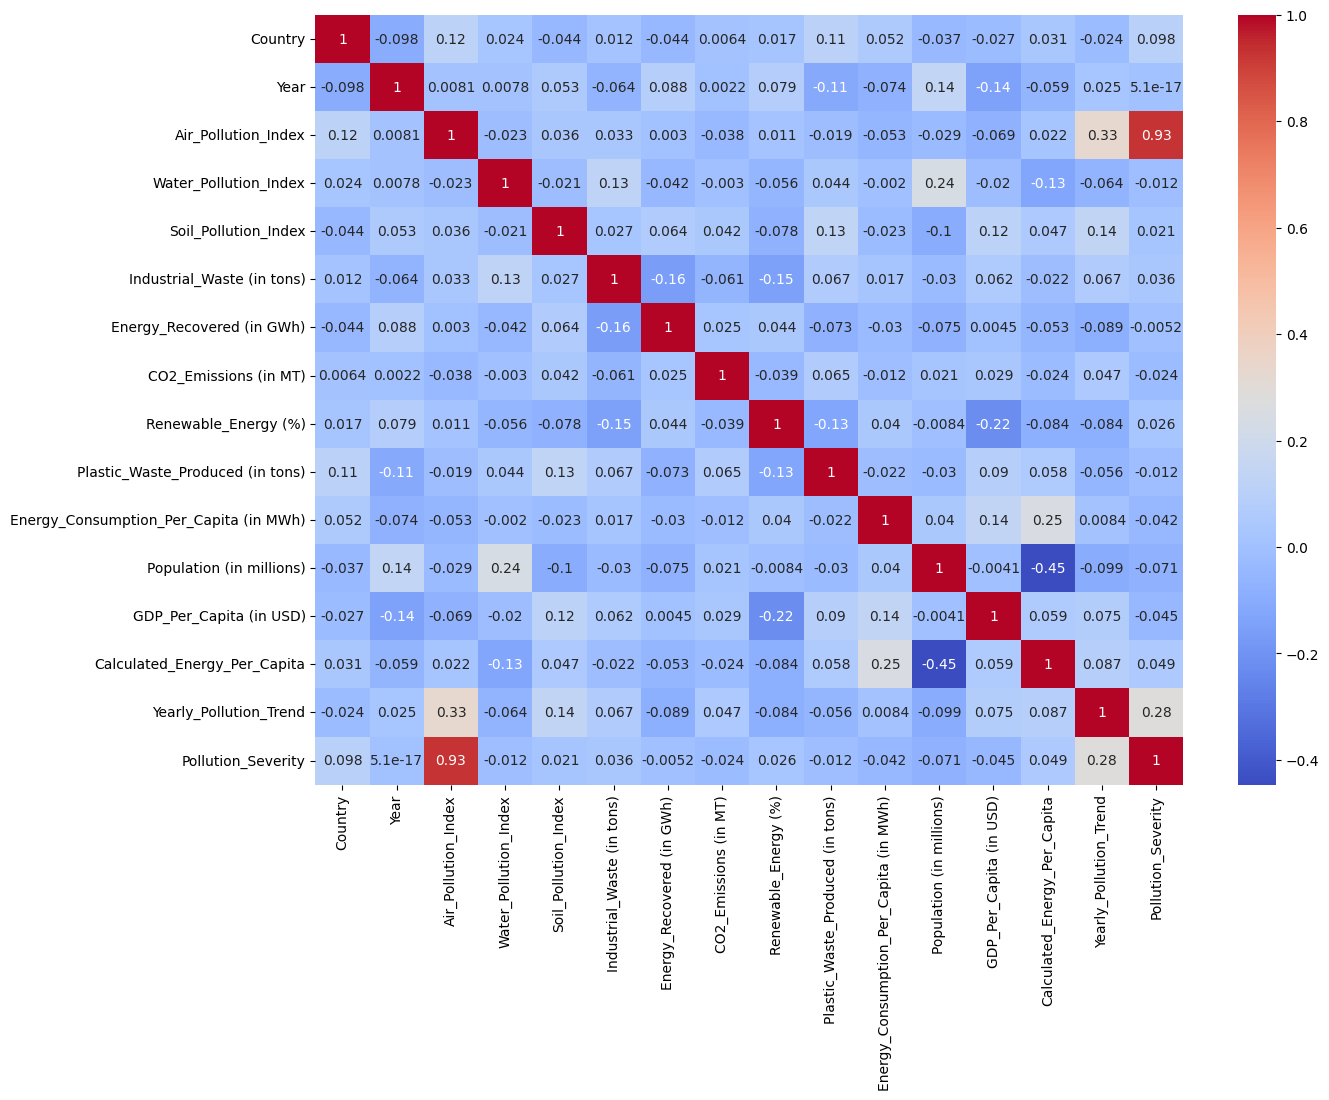

In [11]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

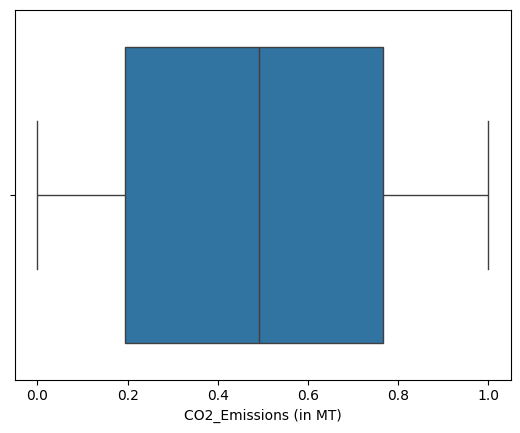

In [12]:
sns.boxplot(x=df['CO2_Emissions (in MT)'])
plt.show()

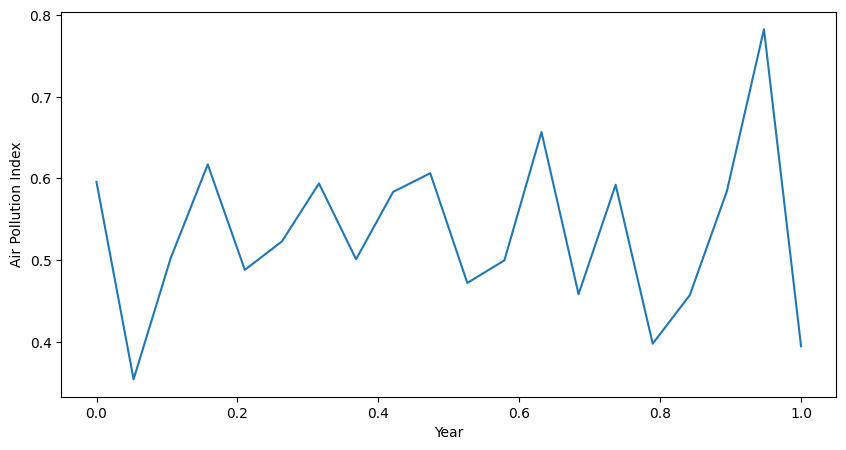

In [13]:
df.groupby('Year')['Air_Pollution_Index'].mean().plot(figsize=(10,5))
plt.ylabel('Air Pollution Index')
plt.show()

In [14]:
X = df.drop(columns=['Pollution_Severity'])
y = df['Pollution_Severity']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

MultinomialNB()

In [17]:
y_pred_nb = nb_model.predict(X_test)

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_nb, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_nb, average='weighted'))

Accuracy: 0.55
Precision: 0.5656067251461988
Recall: 0.55
F1 Score: 0.5226428571428572


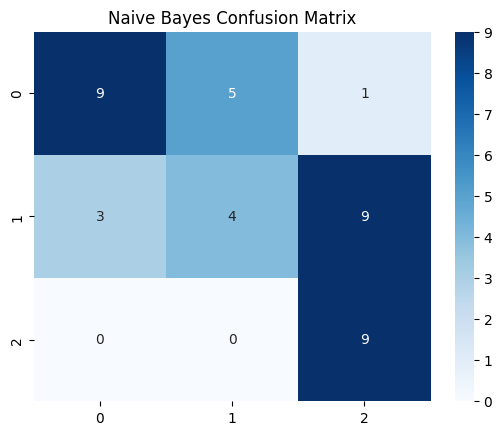

In [19]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

In [20]:
param_grid = {'n_neighbors': [3,5,7,9]}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5
)

grid_knn.fit(X_train, y_train)

best_k = grid_knn.best_params_['n_neighbors']

best_k

9

In [21]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)

knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=9)

In [22]:
y_pred_knn = knn_model.predict(X_test)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_knn, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_knn, average='weighted'))

Accuracy: 0.5
Precision: 0.5093055555555555
Recall: 0.5
F1 Score: 0.5012555899552803


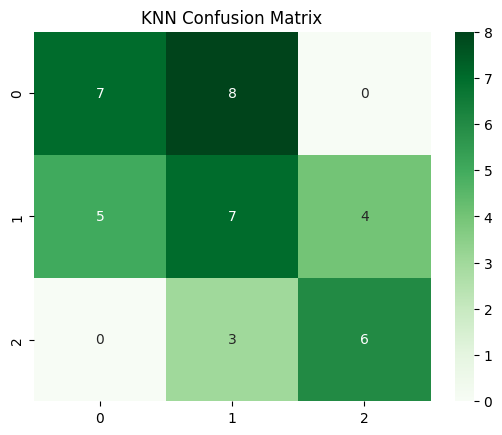

In [24]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title('KNN Confusion Matrix')
plt.show()

In [25]:
param_grid_tree = {
    'max_depth': [3,5,7,10],
    'min_samples_split': [2,5,10]
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree,
    cv=5
)

grid_tree.fit(X_train, y_train)

best_params = grid_tree.best_params_

best_params

{'max_depth': 3, 'min_samples_split': 2}

In [26]:
tree_model = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    random_state=42
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [27]:
y_pred_tree = tree_model.predict(X_test)

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_tree, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_tree, average='weighted'))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


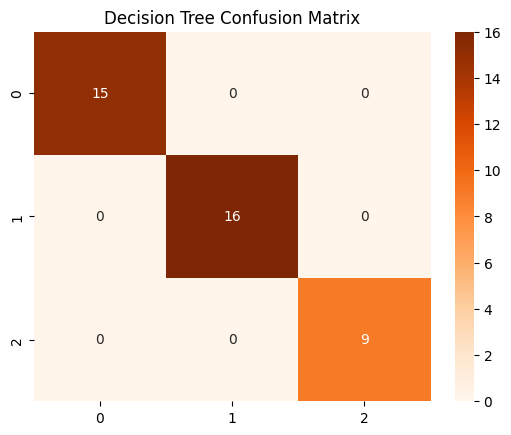

In [29]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Oranges')
plt.title('Decision Tree Confusion Matrix')
plt.show()

In [30]:
print("Naive Bayes Report")
print(classification_report(y_test, y_pred_nb))

print("KNN Report")
print(classification_report(y_test, y_pred_knn))

print("Decision Tree Report")
print(classification_report(y_test, y_pred_tree))

Naive Bayes Report
              precision    recall  f1-score   support

           0       0.75      0.60      0.67        15
           1       0.44      0.25      0.32        16
           2       0.47      1.00      0.64         9

    accuracy                           0.55        40
   macro avg       0.56      0.62      0.54        40
weighted avg       0.57      0.55      0.52        40

KNN Report
              precision    recall  f1-score   support

           0       0.58      0.47      0.52        15
           1       0.39      0.44      0.41        16
           2       0.60      0.67      0.63         9

    accuracy                           0.50        40
   macro avg       0.52      0.52      0.52        40
weighted avg       0.51      0.50      0.50        40

Decision Tree Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        16
           2       1.00 

In [31]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'KNN', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_tree)
    ],
    'Precision': [
        precision_score(y_test, y_pred_nb, average='weighted'),
        precision_score(y_test, y_pred_knn, average='weighted'),
        precision_score(y_test, y_pred_tree, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_nb, average='weighted'),
        recall_score(y_test, y_pred_knn, average='weighted'),
        recall_score(y_test, y_pred_tree, average='weighted')
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test, y_pred_tree, average='weighted')
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.55,0.565607,0.55,0.522643
1,KNN,0.50,0.509306,0.50,0.501256
2,Decision Tree,1.00,1.000000,1.00,1.000000


In [32]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'KNN', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_tree)
    ],
    'Precision': [
        precision_score(y_test, y_pred_nb, average='weighted'),
        precision_score(y_test, y_pred_knn, average='weighted'),
        precision_score(y_test, y_pred_tree, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_nb, average='weighted'),
        recall_score(y_test, y_pred_knn, average='weighted'),
        recall_score(y_test, y_pred_tree, average='weighted')
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test, y_pred_tree, average='weighted')
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.55,0.565607,0.55,0.522643
1,KNN,0.50,0.509306,0.50,0.501256
2,Decision Tree,1.00,1.000000,1.00,1.000000


In [33]:
print("Actionable Insights:")
print("1. High pollution countries require strict environmental regulations.")
print("2. Renewable energy usage can reduce pollution severity.")
print("3. Industrial waste management improves environmental sustainability.")
print("4. Machine learning models help identify pollution trends effectively.")

Actionable Insights:
1. High pollution countries require strict environmental regulations.
2. Renewable energy usage can reduce pollution severity.
3. Industrial waste management improves environmental sustainability.
4. Machine learning models help identify pollution trends effectively.
